# AI Research Assistant

In [34]:
import os
from dotenv import load_dotenv
from tavily import TavilyClient
from langchain_tavily import TavilySearch, TavilyExtract
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from typing import Dict, TypedDict, List, Any 
from dataclasses import dataclass, field
from langgraph.graph import StateGraph, START, END
from langchain_core.output_parsers import JsonOutputParser

In [35]:
load_dotenv()
groq_api_key = os.environ.get("GROQ_API_KEY")
llm = ChatGroq(model="llama-3.3-70b-versatile",api_key=groq_api_key,temperature=0.6)

### Shared State

In [36]:
@dataclass
class SharedState:
    # the user query
    query: str
    # research findings updated by the research agent
    research: List[Dict[str, str]] = field(default_factory=list)
    # summary updated by the analyser
    analysis: str = ""
    # updated by the critic agent
    critique: Dict[str, Any] = field(default_factory=dict)
    # final report updated by the writer agent
    report: str = ""
    # keep track of number of revisions
    revision_count: int = 0
    # make the maximum number of revisions 2 so it caps the number of times this process occurs
    max_revisions: int = 2
    last_agent: str = "START"
    next_agent: str = ""
    logs: List[str] = field(default_factory=list)

In [37]:
class GraphState(TypedDict):
    pipeline_state: SharedState

### Tools

In [66]:
tavily_api_key = os.getenv("TAVILY_API_KEY")
search_engine = TavilySearch(max_results=3) if tavily_api_key else None
extractor = TavilyExtract() if tavily_api_key else None

def web_search(query: str):
    if search_engine is None:
        raise RuntimeError("Search engine has not been initialized.")
    try:
        response = search_engine.invoke({"query": query})
        results = response.get("results", [])
        findings = []
        for result in results:
            findings.append({
                "title": result.get("title", "No Title"),
                "url": result.get("url", ""),
                "snippet": result.get("content", ""), 
                "full_text": "" })               
        return findings
    except Exception as e:
        print(str(e))
        return []

def web_extract(urls):
    if extractor is None:
        raise RuntimeError("Extractor has not been initialized.")
    try:
        extraction_results = extractor.invoke({"urls": urls})
        return extraction_results.get("results", [])
    except Exception as e:
        print(str(e))
        return []

def summariser(findings, query):
    if not findings:
        return "Nothing provided to summarise"
    content = ""
    for index, item in enumerate(findings):
        text = item.get("full_text") or item.get("snippet", "")
        content += f"SOURCE [{index+1}]\n (Title: {item['title']}\n URL: {item['url']}) \n{text}\n"

    if not llm:
        print("Not connected to LLM")
        
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "You are a research analyst. Summarize the provided information into a condensed and well-structured research brief answering the target user query. Only use the given context."),
        ("human", "User Target Query: {query}\n\nContext:\n{content}")
    ])
    
    try:
        chain = prompt_template | llm
        response = chain.invoke({"query": query, "content": content})
        return str(response.content)
    except Exception as e:
        return str(e)
    
def trim_text(text: str, max_chars: int = 4000):
    if not text:
        return ""
    if len(text) <= max_chars:
        return text
    return text[:max_chars] 

### Agents

In [82]:
def researcher_node(state: GraphState):
    p_state = state["pipeline_state"]
    try:
        findings = web_search(query=p_state.query)
        target_urls = []
        for item in findings:
           if item.get("url"):
               target_urls.append(item["url"])
        
        if target_urls:
            contents = web_extract(urls=target_urls)
            extract = {}
            for item in contents:
                url_key = item["url"]
                raw_body = item.get("raw_content", "")
                extract[url_key] = raw_body

            for finding in findings:
                f_url = finding["url"]
                if f_url in extract:
                    finding["full_text"] = extract[f_url]
                    finding["full_text"] = trim_text(raw_body, max_chars=4000)
        p_state.research = findings
        p_state.last_agent = "Research Agent"
    except Exception as e:
        print(f"Research Agent Error: {str(e)}")
        p_state.logs.append(f"Research agent encountered error: {str(e)}")
        return {"pipeline_state": p_state}
    p_state.logs.append("Research agent has found relevant information")
    return {"pipeline_state": p_state}


def analyzer_node(state: GraphState):
    p_state = state["pipeline_state"]
    try:
        summary = summariser(findings=p_state.research, query=p_state.query)
        p_state.analysis = summary
        p_state.last_agent = "Analyser Agent"
    except Exception as e:
        p_state.logs.append(f"Analyser agent encountered error: {str(e)}")
        print(f"Analyzer Agent Error: {str(e)}")
    p_state.logs.append("Analyser agent has produced a summary")
    return {"pipeline_state": p_state}

def critic_node(state: GraphState):
    p_state = state["pipeline_state"]
    sources_text = ""
    for index, f in enumerate(p_state.research):
        context = f.get('full_text') or f.get('snippet', '')
        context = context[:3000]
        sources_text += f"Source [{index+1}] (Title: {f.get('title', 'No Title')}):\n{context}\n"
    prompt_template = ChatPromptTemplate.from_messages([
        ("system",
         "You are a quality assurance critic. Compare the summary against the source text. "
         "Check for factual errors, unsupported claims, contradictions, and missing context. "
         "Evaluate if the summary is generic or full of placeholder text. If the summary uses vague phrases without citing specific examples then set needs_revision to true"
         "and command the analyser to use specific data points from the source text."
         "Only mark needs_revision as true if there is a factual error, unsupported claim or if it's missing important information."
         "Do not mark needs_revision as true over stylistic choices or wording."
         'Respond only with valid JSON (do not use markdown) in this exact format:\n'
         '{{"needs_revision": True/False, "feedback": "specific actionable instructions"}}'),
        ("human",
         "Sources:\n{sources}\n\nSummary to review:\n{analysis}")
    ])
    chain = prompt_template | llm | JsonOutputParser()
    critique_res = chain.invoke({"sources": sources_text, "analysis": p_state.analysis})
    p_state.critique = critique_res
    p_state.last_agent = "Critic Agent"
    verdict = "needs revision" if critique_res.get("needs_revision") else "approved"
    if verdict == "needs revision":
        p_state.logs.append(f"Critic agent has decided revision is necessary. Feedback: {critique_res.get('feedback', '')}")
    elif verdict == "approved":
        p_state.logs.append("Critic agent has decided revision is not necessary.")
    return {"pipeline_state": p_state}

def writer_node(state: GraphState):
    p_state = state["pipeline_state"]
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "You are an expert technical report writer. Format the provided analysis summary into a polished structured report."
         "Have a title, executive summary, key findings and conclusion. Avoid repetition. Do not repeat the same phrases. Vary your vocabulary. Do not be vague."
         "Do not mention implementation errors, API failures or system limitations."
         "Use only the facts provided in the analysis. Do not fabricate."),
        ("human", "Query: {query}\nAnalysis:\n{analysis}")
    ])
    chain = prompt_template | llm
    response = chain.invoke({"query": p_state.query, "analysis": p_state.analysis})
    p_state.report = str(response.content)
    p_state.logs.append("Writer agent has produced a report.")
    p_state.last_agent = "Writer Agent"
    
    return {"pipeline_state": p_state}

def coordinator_node(state: GraphState):
    p_state = state["pipeline_state"]
    if p_state.last_agent == "START":
        next = "Research Agent"
    elif p_state.last_agent == "Research Agent":
        next = "Analyser Agent"
    elif p_state.last_agent == "Analyser Agent":
        next = "Critic Agent"
    if p_state.last_agent == "Critic Agent":
        needs_revision = p_state.critique.get("needs_revision", False)
        if needs_revision and p_state.revision_count < p_state.max_revisions:
            p_state.revision_count += 1
            next = "Analyser Agent"
        else:
            next = "Writer Agent"
    elif p_state.last_agent == "Writer Agent":
        next = "END"
    p_state.next_agent = next
    return {"pipeline_state": p_state}

def coordinator_route(state: GraphState):
    return state["pipeline_state"].next_agent
    

In [83]:
workflow = StateGraph(GraphState)

workflow.add_node("Coordinator Agent", coordinator_node)
workflow.add_node("Research Agent",  researcher_node)
workflow.add_node("Analyser Agent",    analyzer_node)
workflow.add_node("Critic Agent",      critic_node)
workflow.add_node("Writer Agent",      writer_node)

workflow.add_edge(START,         "Coordinator Agent")
workflow.add_edge("Research Agent",  "Coordinator Agent")
workflow.add_edge("Analyser Agent",    "Coordinator Agent")
workflow.add_edge("Critic Agent",      "Coordinator Agent")
workflow.add_edge("Writer Agent",      "Coordinator Agent")

workflow.add_conditional_edges(
    "Coordinator Agent",
    coordinator_route,
    {
        "Research Agent": "Research Agent",
        "Analyser Agent":   "Analyser Agent",
        "Critic Agent":     "Critic Agent",
        "Writer Agent":     "Writer Agent",
        "END":        END,
    },
)

graph = workflow.compile()

### Architecture Diagram

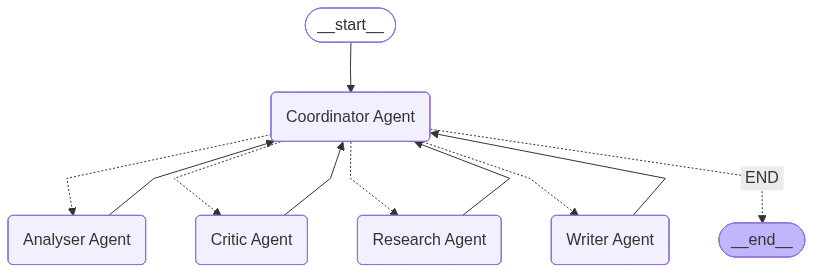

In [24]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

#### Health Benefits of Regular Exercise

In [27]:
query  = "What are the health benefits of regular exercise?"
result = graph.invoke({"pipeline_state": SharedState(query=query)})
final  = result["pipeline_state"]

In [28]:
print(final.report)

The Health Benefits of Regular Exercise: A Comprehensive Analysis

Executive Summary:
Regular exercise is a crucial component of a healthy lifestyle, offering numerous benefits that extend beyond physical health to mental and emotional well-being. This report provides an in-depth analysis of the advantages of regular physical activity, highlighting its impact on mood, weight management, energy levels, and overall health. By understanding the significance of exercise, individuals can take proactive steps to incorporate physical activity into their daily routine and reap the rewards of a healthier, happier life.

Key Findings:
Regular exercise has been shown to have a profound impact on both physical and mental health, leading to improved mood and reduced stress levels by increasing the production of serotonin, dopamine, and norepinephrine. Additionally, physical activity plays a critical role in weight management, building and maintaining strong muscles and bones, and increasing energy 

In [29]:
print(final.logs)

['Research agent has found relevant information', 'Analyser agent has found produced a summary', 'Critic agent has decided revision is not necessary.', 'Writer agent has produced a report.']


In [30]:
print(final.analysis)

**Research Brief: Health Benefits of Regular Exercise**

Regular exercise offers numerous health benefits, both physically and mentally. The top 10 benefits of regular physical activity include:

1. **Improved mood and reduced stress**: Exercise can increase levels of serotonin, dopamine, and norepinephrine, helping to regulate mood and reduce symptoms of depression and anxiety.
2. **Weight management**: Regular physical activity can help maintain a moderate weight, increase metabolic rate, and burn calories.
3. **Stronger muscles and bones**: Exercise can build and maintain strong muscles and bones, reducing the risk of injury and osteoporosis.
4. **Increased energy levels**: Physical activity can boost energy levels and reduce fatigue by improving cardiovascular health and increasing oxygen delivery to the muscles.
5. **Reduced risk of chronic disease**: Regular exercise can reduce the risk of chronic diseases, such as heart disease, diabetes, and certain types of cancer.
6. **Improv

In [31]:
print(final.critique)

{'needs_revision': False, 'feedback': 'The summary accurately reflects the source text, covering the top 10 benefits of regular exercise and providing supporting evidence from various studies and organizations. The summary is well-structured, easy to follow, and free of factual errors, unsupported claims, and contradictions.'}


In [32]:
print(final.research)

[{'title': 'The Top 10 Benefits of Regular Physical Activity', 'url': 'https://www.healthline.com/nutrition/10-benefits-of-exercise', 'snippet': '# The Top 10 Benefits of Regular Exercise. Exercise is defined as any movement that makes your muscles work and requires your body to burn calories. Here are the top 10 ways regular exercise benefits your body and brain. Research has shown that exercise may improve your mood and decrease feelings of depression, anxiety, and stress. The authors of a 2025 study reported that moderate exercise of 10 to 30 minutes is effective at improving mood. Physical activity may also increase the release of endorphins, which help produce positive feelings and reduce the perception of pain. However, your metabolic rate — the speed at which you burn fat — may slow with time in a calorie deficit and as you lose weight. This can burn more calories and help you manage your weight. This is known as body recomposition, which could help you maintain lean muscle and 

#### Applications of AI in healthcare

In [64]:
query  = "Applications of AI in healthcare"
result = graph.invoke({"pipeline_state": SharedState(query=query)})
final  = result["pipeline_state"]
print(final.report)

**Title:** Leveraging Artificial Intelligence in Healthcare: Enhancing Patient Care and Efficiency

**Executive Summary:**
The integration of artificial intelligence (AI) in healthcare is transforming the industry by optimizing medical processes, enhancing patient care, and increasing operational efficiency. This report highlights the key applications, technologies, and examples of AI in healthcare, underscoring its potential to revolutionize the sector.

**Key Findings:**
The applications of AI in healthcare are multifaceted, with notable examples including:
* Accurate diagnosis of diseases through the analysis of medical images, patient data, and health records
* Creation of personalized treatment plans tailored to individual patients' medical histories, genetic profiles, and lifestyles
* Automation of documentation, reducing administrative burdens and improving accuracy
* Streamlined medical coding and billing processes, minimizing errors and enhancing efficiency
The report also ide

### Max Revisions

In [78]:
def always_revise_critic(state):
    p = state["pipeline_state"]
    p.critique = {"needs_revision": True, "feedback": "The analysis needs more substance. It should cite specific data points and be less vague."}
    p.logs.append("Testing max_revisions revision cap for Critic Agent")
    p.last_agent = "Critic Agent"
    return {"pipeline_state": p}

wf = StateGraph(GraphState)
wf.add_node("Coordinator Agent", coordinator_node)
wf.add_node("Research Agent",  researcher_node)
wf.add_node("Analyser Agent",    analyzer_node)
wf.add_node("Critic Agent",      always_revise_critic)
wf.add_node("Writer Agent",      writer_node)
wf.add_edge(START,        "Coordinator Agent")
wf.add_edge("Research Agent", "Coordinator Agent")
wf.add_edge("Analyser Agent",   "Coordinator Agent")
wf.add_edge("Critic Agent",     "Coordinator Agent")
wf.add_edge("Writer Agent",     "Coordinator Agent")
wf.add_conditional_edges("Coordinator Agent", coordinator_route,
    {"Research Agent": "Research Agent", "Analyser Agent": "Analyser Agent",
     "Critic Agent": "Critic Agent", "Writer Agent": "Writer Agent", "END": END})
test_graph = wf.compile()

In [79]:
query  = "Applications of AI in healthcare"
result = test_graph.invoke({"pipeline_state": SharedState(query=query)})
final  = result["pipeline_state"]
print(final.revision_count)

2


In [80]:
print(final.logs)

['Research agent has found relevant information', 'Analyser agent has produced a summary', 'Testing max_revisions revision cap for Critic Agent', 'Analyser agent has produced a summary', 'Testing max_revisions revision cap for Critic Agent', 'Analyser agent has produced a summary', 'Testing max_revisions revision cap for Critic Agent', 'Writer agent has produced a report.']


In [81]:
print(final.report)

**Title:** Harnessing Artificial Intelligence in Healthcare: A Transformative Opportunity

**Executive Summary:**
The integration of Artificial Intelligence (AI) in healthcare is poised to revolutionize the medical landscape, offering unprecedented opportunities to enhance patient care, improve outcomes, and reduce costs. By leveraging AI's analytical capabilities, healthcare providers can unlock new avenues for personalized treatment, remote monitoring, and data-driven insights, ultimately contributing to the attainment of the "quadruple aim" of improved population health, patient experience, caregiver experience, and cost reduction.

**Key Findings:**
The applications of AI in healthcare are multifaceted and far-reaching, with notable examples including:
- The analysis of vast medical datasets to inform personalized treatment recommendations and elevate patient care standards.
- The development of digital health platforms that facilitate patient engagement, remote monitoring, and str